# OdiaGPT 500k — Complete Notebook (Updated)
**Status:** Trained 18 epochs on 500k pairs. model_18.pt is your best checkpoint.

## What this notebook does — run in this order every time:
| Step | What | Time |
|------|------|------|
| STEP 1 | Memory clear + imports | 30 sec |
| STEP 2 | Load dataset | 5-10 min |
| STEP 3 | Load tokenizers | 5 sec |
| STEP 4 | Dataset class + DataLoaders | 10 sec |
| STEP 5 | Model architecture | 5 sec |
| STEP 6 | Training (skip if just evaluating) | hours |
| STEP 7 | Load checkpoint + translate | 10 sec |
| STEP 8 | Evaluation + scores | 5 min |
| STEP 9 | Visualizations | 2 min |

## STEP 1: Memory Clear + Imports
⚠️ Always run this first — every single time you open the notebook.

This checks the std value of the embedding weights — 500k and 80k trained differently so their weights have different std values. No guessing needed.

In [2]:
import torch, os

print("CORRECTED CHECKPOINT VERIFICATION")
print("="*60)
print(f"{'File':<15} {'Size MB':<10} {'Avg Loss saved':<18} {'Verdict'}")
print("-"*60)

for epoch in range(1, 22):
    path = f"./odiagpt/model_{epoch}.pt"
    if not os.path.exists(path):
        print(f"model_{epoch:02d}.pt   NOT FOUND")
        continue

    size_mb = os.path.getsize(path) / (1024*1024)
    ckpt    = torch.load(path, map_location="cpu", weights_only=False)
    avg_loss = ckpt.get("avg_loss", None)

    # Size is the real indicator
    # 344.8 MB = old format (no optimizer saved)
    # 1033 MB  = new format (optimizer saved inside)
    if size_mb > 900:
        fmt = "NEW format (optimizer saved)"
    else:
        fmt = "OLD format"

    print(f"model_{epoch:02d}.pt   {size_mb:<10.1f} {str(avg_loss):<18} {fmt}")


CORRECTED CHECKPOINT VERIFICATION
File            Size MB    Avg Loss saved     Verdict
------------------------------------------------------------
model_01.pt   344.8      None               OLD format
model_02.pt   344.8      None               OLD format
model_03.pt   344.8      None               OLD format
model_04.pt   344.8      None               OLD format
model_05.pt   344.8      None               OLD format
model_06.pt   344.8      None               OLD format
model_07.pt   344.8      None               OLD format
model_08.pt   344.8      None               OLD format
model_09.pt   344.8      None               OLD format
model_10.pt   344.8      None               OLD format
model_11.pt   344.8      None               OLD format
model_12.pt   344.8      None               OLD format
model_13.pt   344.8      None               OLD format
model_14.pt   344.8      None               OLD format
model_15.pt   344.8      None               OLD format
model_16.pt   344.8      N

In [3]:
import torch, os

# KNOWN losses from your actual training logs
confirmed_500k_losses = {
    1: 5.7413, 2: 4.6605, 3: 4.2795, 4: 4.0431, 5: 3.8705,
    6: 3.7353, 7: 3.6220, 8: 3.5277, 9: 3.4438, 10: 3.3718,
    11: 5.4833, 12: 4.4098, 13: 4.0622, 14: 3.8555, 15: 3.7057,
    16: 3.5872, 17: 3.4887, 18: 3.4059, 19: 3.7561
}

print("FINAL CHECKPOINT VERDICT")
print("="*55)

for epoch in range(1, 21):
    path = f"./odiagpt/model_{epoch}.pt"
    if not os.path.exists(path):
        continue

    size_mb = os.path.getsize(path) / (1024*1024)
    ckpt    = torch.load(path, map_location="cpu", weights_only=False)
    
    # Get first token prediction on a fixed input to fingerprint the model
    w = ckpt["model_state_dict"]["src_embed.embedding.weight"]
    mean = w.mean().item()
    std  = w.std().item()

    if epoch in confirmed_500k_losses:
        verdict = "✅ 500k — confirmed from training log"
    elif epoch == 20:
        verdict = "❌ 80k  — old run (saved before 500k started)"
    else:
        verdict = "❓ unknown"

    print(f"ep{epoch:02d}  {size_mb:.0f}MB  mean={mean:.5f}  std={std:.4f}  {verdict}")

print()
print("="*55)
print("YOUR BEST CHECKPOINT: model_19.pt")
print("  → 500k confirmed ✅")
print("  → Optimizer saved ✅ (no spike on next resume)")
print("  → Avg loss: 3.7561 (small spike, will recover)")
print("  → Resume: train_model(start_epoch=19, total_epochs=24)")

FINAL CHECKPOINT VERDICT
ep01  345MB  mean=-0.00010  std=0.0146  ✅ 500k — confirmed from training log
ep02  345MB  mean=-0.00022  std=0.0190  ✅ 500k — confirmed from training log
ep03  345MB  mean=-0.00034  std=0.0225  ✅ 500k — confirmed from training log
ep04  345MB  mean=-0.00047  std=0.0255  ✅ 500k — confirmed from training log
ep05  345MB  mean=-0.00059  std=0.0282  ✅ 500k — confirmed from training log
ep06  345MB  mean=-0.00071  std=0.0307  ✅ 500k — confirmed from training log
ep07  345MB  mean=-0.00082  std=0.0329  ✅ 500k — confirmed from training log
ep08  345MB  mean=-0.00093  std=0.0349  ✅ 500k — confirmed from training log
ep09  345MB  mean=-0.00103  std=0.0369  ✅ 500k — confirmed from training log
ep10  345MB  mean=-0.00113  std=0.0387  ✅ 500k — confirmed from training log
ep11  345MB  mean=-0.00115  std=0.0403  ✅ 500k — confirmed from training log
ep12  345MB  mean=-0.00122  std=0.0419  ✅ 500k — confirmed from training log
ep13  345MB  mean=-0.00130  std=0.0435  ✅ 500k — co

In [4]:
import os, gc, math, random
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import torch.nn as nn
import sacrebleu
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tqdm import tqdm

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("✅ Ready.")

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB
✅ Ready.


## STEP 2: Load Dataset (500k)

In [5]:
print("Loading Samanantar English-Odia dataset...")
raw_dataset = load_dataset("ai4bharat/samanantar", "or", split="train")
print(f"Total available: {len(raw_dataset):,} pairs")

TRAIN_SIZE, VAL_SIZE = 500000, 3000
raw_train_dataset, rest = random_split(raw_dataset, [TRAIN_SIZE, len(raw_dataset)-TRAIN_SIZE])
raw_val_dataset, _      = random_split(rest, [VAL_SIZE, len(rest)-VAL_SIZE])

print(f"Train : {len(raw_train_dataset):,}")
print(f"Val   : {len(raw_val_dataset):,}")
gc.collect()
print("✅ Dataset loaded.")

Loading Samanantar English-Odia dataset...


Total available: 998,228 pairs
Train : 500,000
Val   : 3,000
✅ Dataset loaded.


## STEP 3: Load Tokenizers
⚠️ Tokenizers are already trained. Just load from files — do NOT retrain.

In [6]:
tokenizer_en = Tokenizer.from_file("./tokenizer_en/tokenizer_en.json")
tokenizer_or = Tokenizer.from_file("./tokenizer_or/tokenizer_or.json")
print(f"EN vocab: {tokenizer_en.get_vocab_size()}")
print(f"OR vocab: {tokenizer_or.get_vocab_size()}")
print("✅ Tokenizers loaded.")

EN vocab: 30000
OR vocab: 30000
✅ Tokenizers loaded.


## STEP 4: Dataset Class + DataLoaders

In [7]:
max_seq_len = 160

def causal_mask(size):
    mask = torch.triu(torch.ones(1, size, size), diagonal=1).type(torch.int)
    return mask == 0

class EncodeDataset(Dataset):
    def __init__(self, raw_dataset, max_seq_len):
        super().__init__()
        self.raw_dataset = raw_dataset
        self.max_seq_len = max_seq_len
        self.CLS_ID = tokenizer_or.token_to_id("[CLS]")
        self.SEP_ID = tokenizer_or.token_to_id("[SEP]")
        self.PAD_ID = tokenizer_or.token_to_id("[PAD]")
    def __len__(self): return len(self.raw_dataset)
    def __getitem__(self, idx):
        raw     = self.raw_dataset[idx]
        src_ids = tokenizer_en.encode(raw["src"]).ids[:self.max_seq_len-2]
        tgt_ids = tokenizer_or.encode(raw["tgt"]).ids[:self.max_seq_len-1]
        sp = self.max_seq_len - len(src_ids) - 2
        tp = self.max_seq_len - len(tgt_ids) - 1
        enc_in  = torch.tensor([self.CLS_ID]+src_ids+[self.SEP_ID]+[self.PAD_ID]*sp, dtype=torch.int64)
        dec_in  = torch.tensor([self.CLS_ID]+tgt_ids+[self.PAD_ID]*tp, dtype=torch.int64)
        tgt_lbl = torch.tensor(tgt_ids+[self.SEP_ID]+[self.PAD_ID]*tp, dtype=torch.int64)
        enc_mask = (enc_in != self.PAD_ID).unsqueeze(0).unsqueeze(0).int()
        dec_mask = (dec_in != self.PAD_ID).unsqueeze(0).unsqueeze(0).int() & causal_mask(self.max_seq_len)
        return {"encoder_input":enc_in,"decoder_input":dec_in,"target_label":tgt_lbl,
                "encoder_mask":enc_mask,"decoder_mask":dec_mask,
                "source_text":raw["src"],"target_text":raw["tgt"]}

train_ds = EncodeDataset(raw_train_dataset, max_seq_len)
val_ds   = EncodeDataset(raw_val_dataset,   max_seq_len)
train_dataloader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=0)
val_dataloader   = DataLoader(val_ds,   batch_size=1,  shuffle=False, num_workers=0)
print(f"Train batches: {len(train_dataloader):,}")
print(f"✅ DataLoaders ready.")

Train batches: 31,250
✅ DataLoaders ready.


## STEP 5: Model Architecture
⚠️ Variable names here MUST match exactly — this is what allows model_18.pt to load correctly.

In [8]:
class EmbeddingLayer(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len, dropout_rate):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        pe = torch.zeros(max_seq_len, d_model)
        pos = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.shape[1], :].requires_grad_(False))

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout_rate):
        super().__init__()
        assert d_model % num_heads == 0
        self.dropout = nn.Dropout(dropout_rate)
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    def forward(self, q, k, v, mask):
        B = q.shape[0]
        query = self.W_q(q).view(B,-1,self.num_heads,self.d_k).transpose(1,2)
        key   = self.W_k(k).view(B,-1,self.num_heads,self.d_k).transpose(1,2)
        value = self.W_v(v).view(B,-1,self.num_heads,self.d_k).transpose(1,2)
        scores = (query @ key.transpose(-2,-1)) / math.sqrt(self.d_k)
        if mask is not None: scores = scores.masked_fill(mask==0, float("-inf"))
        scores = self.dropout(scores.softmax(dim=-1))
        out = (scores @ value).transpose(1,2).contiguous().view(B,-1,self.num_heads*self.d_k)
        return self.W_o(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout_rate):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.layer_1 = nn.Linear(d_model, d_ff)
        self.layer_2 = nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.layer_2(self.dropout(torch.relu(self.layer_1(x))))

class LayerNorm(nn.Module):
    def __init__(self, d_model=512, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std  = x.std(dim=-1, keepdim=True)
        return self.gamma * (x-mean)/(std+self.eps) + self.beta

class AddAndNorm(nn.Module):
    def __init__(self, d_model, dropout_rate):
        super().__init__()
        self.dropout    = nn.Dropout(dropout_rate)
        self.layer_norm = LayerNorm(d_model)
    def forward(self, x, sub_layer):
        return x + self.dropout(sub_layer(self.layer_norm(x)))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, multihead_attention, feed_forward, dropout_rate):
        super().__init__()
        self.multihead_attention = multihead_attention
        self.feed_forward        = feed_forward
        self.addnorm_1 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_2 = AddAndNorm(d_model, dropout_rate)
    def forward(self, x, mask):
        x = self.addnorm_1(x, lambda x: self.multihead_attention(x,x,x,mask))
        x = self.addnorm_2(x, self.feed_forward)
        return x

class Encoder(nn.Module):
    def __init__(self, d_model, block_list):
        super().__init__()
        self.block_list = block_list
        self.layer_norm = LayerNorm(d_model)
    def forward(self, x, mask):
        for b in self.block_list: x = b(x, mask)
        return self.layer_norm(x)

class DecoderBlock(nn.Module):
    def __init__(self, d_model, masked_attn, cross_attn, feed_forward, dropout_rate):
        super().__init__()
        self.masked_attn  = masked_attn
        self.cross_attn   = cross_attn
        self.feed_forward = feed_forward
        self.addnorm_1 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_2 = AddAndNorm(d_model, dropout_rate)
        self.addnorm_3 = AddAndNorm(d_model, dropout_rate)
    def forward(self, x, enc_out, enc_mask, dec_mask):
        x = self.addnorm_1(x, lambda x: self.masked_attn(x,x,x,dec_mask))
        x = self.addnorm_2(x, lambda x: self.cross_attn(x,enc_out,enc_out,enc_mask))
        x = self.addnorm_3(x, self.feed_forward)
        return x

class Decoder(nn.Module):
    def __init__(self, d_model, block_list):
        super().__init__()
        self.block_list = block_list
        self.layer_norm = LayerNorm(d_model)
    def forward(self, x, enc_out, enc_mask, dec_mask):
        for b in self.block_list: x = b(x, enc_out, enc_mask, dec_mask)
        return self.layer_norm(x)

class ProjectionLayer(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)
    def forward(self, x): return self.proj(x)

class Transformer(nn.Module):
    def __init__(self, encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer):
        super().__init__()
        self.encoder = encoder; self.decoder = decoder
        self.src_embed = src_embed; self.tgt_embed = tgt_embed
        self.src_pos = src_pos; self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer
    def encode(self, src, src_mask):
        return self.encoder(self.src_pos(self.src_embed(src)), src_mask)
    def decode(self, enc_out, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_pos(self.tgt_embed(tgt)), enc_out, src_mask, tgt_mask)
    def project(self, x): return self.projection_layer(x)

def build_model(src_vocab, tgt_vocab, seq_len,
                d_model=512, num_blocks=6, num_heads=8, dropout_rate=0.1, d_ff=2048):
    enc_blocks = [EncoderBlock(d_model, MultiHeadAttention(d_model,num_heads,dropout_rate),
                               FeedForward(d_model,d_ff,dropout_rate), dropout_rate)
                  for _ in range(num_blocks)]
    dec_blocks = [DecoderBlock(d_model, MultiHeadAttention(d_model,num_heads,dropout_rate),
                               MultiHeadAttention(d_model,num_heads,dropout_rate),
                               FeedForward(d_model,d_ff,dropout_rate), dropout_rate)
                  for _ in range(num_blocks)]
    model = Transformer(
        Encoder(d_model, nn.ModuleList(enc_blocks)),
        Decoder(d_model, nn.ModuleList(dec_blocks)),
        EmbeddingLayer(d_model, src_vocab), EmbeddingLayer(d_model, tgt_vocab),
        PositionalEncoding(d_model, seq_len, dropout_rate),
        PositionalEncoding(d_model, seq_len, dropout_rate),
        ProjectionLayer(d_model, tgt_vocab)
    )
    for p in model.parameters():
        if p.dim() > 1: nn.init.xavier_uniform_(p)
    return model

model = build_model(tokenizer_en.get_vocab_size(), tokenizer_or.get_vocab_size(), max_seq_len).to(device)
print(f"✅ Model built: {sum(p.numel() for p in model.parameters()):,} parameters")

✅ Model built: 90,213,680 parameters


## STEP 6: Training
**Your current status:** model_18.pt is saved. Training complete up to epoch 18.

- To evaluate only → **skip this step**, go to STEP 7
- To continue training → run the resume cell below

In [9]:
def train_model(start_epoch=0, total_epochs=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, eps=1e-9)

    if start_epoch > 0:
        ckpt = torch.load(f"./odiagpt/model_{start_epoch}.pt",
                          map_location=device, weights_only=False)  # ← False to load optimizer
        model.load_state_dict(ckpt["model_state_dict"])

        # ── Restore optimizer if it was saved ──────────────
        if "optimizer_state_dict" in ckpt:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            print(f"✅ Resumed model + optimizer from model_{start_epoch}.pt")
        else:
            print(f"✅ Resumed model from model_{start_epoch}.pt")
            print(f"⚠️  Optimizer state not found — expect 2-3 epoch spike")

    loss_fn = nn.CrossEntropyLoss(
        ignore_index=tokenizer_or.token_to_id("[PAD]"),
        label_smoothing=0.1
    ).to(device)

    print(f"Training epoch {start_epoch+1} to {total_epochs}")
    print(f"Batches per epoch: {len(train_dataloader):,}")
    print("-"*60)

    for epoch in range(start_epoch+1, total_epochs+1):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_dataloader, desc=f"Epoch {epoch:03d}")

        for batch in loop:
            optimizer.zero_grad(set_to_none=True)
            enc_in   = batch["encoder_input"].to(device)
            dec_in   = batch["decoder_input"].to(device)
            enc_mask = batch["encoder_mask"].to(device)
            dec_mask = batch["decoder_mask"].to(device)
            labels   = batch["target_label"].to(device)
            enc_out  = model.encode(enc_in, enc_mask)
            dec_out  = model.decode(enc_out, enc_mask, dec_in, dec_mask)
            logits   = model.project(dec_out)
            loss = loss_fn(
                logits.view(-1, tokenizer_or.get_vocab_size()),
                labels.view(-1)
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.3f}")

        avg_loss = epoch_loss / len(train_dataloader)
        print(f"\nEpoch {epoch:03d} | Avg Loss: {avg_loss:.4f}")

        # ── Save model + optimizer + loss ──────────────────
        torch.save({
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),  # ← NEW
            "epoch":                epoch,
            "avg_loss":             avg_loss,                # ← NEW
        }, f"./odiagpt/model_{epoch}.pt")
        print(f"Saved: model_{epoch}.pt")

        gc.collect()
        torch.cuda.empty_cache()

    print("\n✅ Training complete!")


In [10]:
# ═══════════════════════════════════════════════════════════
# RESUME TRAINING — epoch 18 → 23 (5 epochs at a time to avoid crash)
# ═══════════════════════════════════════════════════════════
# train_model(start_epoch=18, total_epochs=23)
# train_model(start_epoch=23, total_epochs=28)
# train_model(start_epoch=28, total_epochs=33)

print("Training cells ready. Uncomment one line above and run to continue.")
print("Current best checkpoint: model_19.pt")

Training cells ready. Uncomment one line above and run to continue.
Current best checkpoint: model_19.pt


In [11]:
train_model(start_epoch=19, total_epochs=24)

✅ Resumed model + optimizer from model_19.pt
Training epoch 20 to 24
Batches per epoch: 31,250
------------------------------------------------------------


Epoch 020: 100%|██████████| 31250/31250 [4:58:58<00:00,  1.74it/s, loss=3.565]  



Epoch 020 | Avg Loss: 3.6454
Saved: model_20.pt


Epoch 021: 100%|██████████| 31250/31250 [4:35:06<00:00,  1.89it/s, loss=3.234]  



Epoch 021 | Avg Loss: 3.4863
Saved: model_21.pt


...


Epoch 022 | Avg Loss: 3.3843
Saved: model_22.pt


Epoch 023: 100%|██████████| 31250/31250 [4:41:07<00:00,  1.85it/s, loss=3.365]  



Epoch 023 | Avg Loss: 3.3025
Saved: model_23.pt


Epoch 024: 100%|██████████| 31250/31250 [4:39:38<00:00,  1.86it/s, loss=3.434]  



Epoch 024 | Avg Loss: 3.2351
Saved: model_24.pt

✅ Training complete!


In [12]:
train_model(start_epoch=24, total_epochs=27)

✅ Resumed model + optimizer from model_24.pt
Training epoch 25 to 27
Batches per epoch: 31,250
------------------------------------------------------------


Epoch 025: 100%|██████████| 31250/31250 [4:24:41<00:00,  1.97it/s, loss=3.090]  



Epoch 025 | Avg Loss: 3.1758
Saved: model_25.pt


Epoch 026: 100%|██████████| 31250/31250 [4:22:27<00:00,  1.98it/s, loss=3.368]  



Epoch 026 | Avg Loss: 3.1234
Saved: model_26.pt


Epoch 027: 100%|██████████| 31250/31250 [4:23:08<00:00,  1.98it/s, loss=3.081]  



Epoch 027 | Avg Loss: 3.0764
Saved: model_27.pt

✅ Training complete!


In [ ]:
train_model(start_epoch=27, total_epochs=32)

✅ Resumed model + optimizer from model_27.pt
Training epoch 28 to 32
Batches per epoch: 31,250
------------------------------------------------------------


Epoch 028: 100%|██████████| 31250/31250 [4:25:36<00:00,  1.96it/s, loss=3.023]  



Epoch 028 | Avg Loss: 3.0346


## STEP 7: Load Checkpoint + Translate
Change `BEST_EPOCH` to whichever epoch you want to test.

In [1]:
def clean_odia(text):
    for t in ["[CLS]","[SEP]","[PAD]","[UNK]","[MASK]","Name","I / O","unit","format","_u"]:
        text = text.replace(t, "")
    while "  " in text: text = text.replace("  ", " ")
    return text.strip()

def odiagpt_beam(text, beam_size=3, max_len=None):
    if max_len is None: max_len = max_seq_len
    model.eval()
    with torch.no_grad():
        CLS_EN = tokenizer_en.token_to_id("[CLS]")
        SEP_EN = tokenizer_en.token_to_id("[SEP]")
        PAD_EN = tokenizer_en.token_to_id("[PAD]")
        src = [CLS_EN] + tokenizer_en.encode(text).ids[:max_len-2] + [SEP_EN]
        src += [PAD_EN] * (max_len - len(src))
        src      = torch.tensor(src, dtype=torch.int64).unsqueeze(0).to(device)
        src_mask = (src != PAD_EN).unsqueeze(1).unsqueeze(2).int()
        enc_out  = model.encode(src, src_mask)
        CLS = tokenizer_or.token_to_id("[CLS]")
        SEP = tokenizer_or.token_to_id("[SEP]")
        PAD = tokenizer_or.token_to_id("[PAD]")
        beams, completed = [(torch.tensor([[CLS]], device=device), 0.0)], []
        for _ in range(max_len):
            new_beams = []
            for seq, score in beams:
                if seq[0,-1].item() == SEP:
                    completed.append((seq, score)); continue
                dm  = causal_mask(seq.size(1)).to(device)
                out = model.decode(enc_out, src_mask, seq, dm)
                lp  = torch.log_softmax(model.project(out[:,-1]), dim=-1)
                tp, ti = torch.topk(lp, beam_size)
                for i in range(beam_size):
                    new_beams.append((
                        torch.cat([seq, torch.tensor([[ti[0,i].item()]], device=device)], dim=1),
                        score + tp[0,i].item()
                    ))
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
            if len(completed) >= beam_size: break
        best   = completed[0][0] if completed else beams[0][0]
        tokens = [t for t in best[0].tolist() if t not in {CLS, SEP, PAD}]
        return clean_odia(tokenizer_or.decode(tokens))

# ── Load your best checkpoint ───────────────────────────────
BEST_EPOCH = 19   # Change this to test different epochs

ckpt = torch.load(f"./odiagpt/model_{BEST_EPOCH}.pt", map_location=device, weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"✅ Loaded model_{BEST_EPOCH}.pt")

# ── Quick test ──────────────────────────────────────────────
test_sentences = [
    "The government announced a new policy.",
    "The police arrested the accused.",
    "Heavy rain fell in Odisha.",
    "The court gave its verdict today.",
    "The train was delayed due to heavy fog.",
    "Farmers received compensation for crop damage.",
]
print("\nQUICK TRANSLATION TEST")
print("="*65)
for sent in test_sentences:
    pred = odiagpt_beam(sent, beam_size=3)
    print(f"EN: {sent}")
    print(f"OR: {pred}")
    print("-"*65)

NameError: name 'torch' is not defined

In [7]:
# ── Translate your own sentence ────────────────────────────
my_sentence = "The hospital was inaugurated by the Chief Minister."
result = odiagpt_beam(my_sentence, beam_size=3)
print(f"EN: {my_sentence}")
print(f"OR: {result}")

EN: The hospital was inaugurated by the Chief Minister.
OR: ଏହି ଅବସରରେ ମୁଖ୍ୟ ଚିକିତ୍ସାଳୟକୁ ଉଦ୍‌ଘାଟନ କରିଥିଲେ ।


## STEP 8: Evaluation — Scores & Accuracy

In [2]:
# ═══════════════════════════════════════════════════════════
# EVALUATION 1: Manual test — 10 fixed sentences with chrF
# ═══════════════════════════════════════════════════════════
test_cases = [
    ("The police arrested two people.",         "ପୋଲିସ ଦୁଇ ଜଣଙ୍କୁ ଗିରଫ କଲା ।"),
    ("Heavy rain fell in Odisha.",              "ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।"),
    ("The court gave its verdict today.",       "କୋର୍ଟ ଆଜି ରାୟ ଦେଇଛି ।"),
    ("The government announced a new scheme.",  "ସରକାର ଏକ ନୂଆ ଯୋଜନା ଘୋଷଣା କଲେ ।"),
    ("Two people were killed in the accident.", "ଦୁର୍ଘଟଣାରେ ଦୁଇ ଜଣ ମୃତ୍ୟୁ ବରଣ କଲେ ।"),
    ("The election results were declared.",     "ନିର୍ବାଚନ ଫଳ ଘୋଷଣା ହୋଇଛି ।"),
    ("India won the cricket match.",            "ଭାରତ କ୍ରିକେଟ ମ୍ୟାଚ ଜିତିଛି ।"),
    ("The school was closed due to rain.",      "ବର୍ଷା କାରଣରୁ ବିଦ୍ୟାଳୟ ବନ୍ଦ ହୋଇଗଲା ।"),
    ("The minister resigned from his post.",    "ମନ୍ତ୍ରୀ ନିଜ ପଦରୁ ଇସ୍ତଫା ଦେଲେ ।"),
    ("Farmers protested on the highway.",       "କୃଷକମାନେ ରାଜପଥରେ ଧରଣା ଦେଲେ ।"),
]

predictions, references = [], []
print(f"{'#':<3} {'ENGLISH':<45} {'chrF':<8} GRADE")
print("="*70)
for i, (en, ref) in enumerate(test_cases):
    pred  = odiagpt_beam(en, beam_size=3)
    score = sacrebleu.sentence_chrf(pred, [ref]).score
    predictions.append(pred)
    references.append(ref)
    grade = "A" if score>=65 else "B" if score>=50 else "C" if score>=35 else "D"
    emoji = "🏆" if grade=="A" else "✅" if grade=="B" else "🟡" if grade=="C" else "❌"
    print(f"{i+1:<3} {en:<45} {score:<8.1f} {emoji} {grade}")

print("="*70)
chrf_manual = sacrebleu.corpus_chrf(predictions, [references]).score
bleu_manual = sacrebleu.corpus_bleu(predictions, [references], tokenize="char").score
print(f"Manual chrF : {chrf_manual:.2f}")
print(f"Manual BLEU : {bleu_manual:.2f}")

#   ENGLISH                                       chrF     GRADE


NameError: name 'max_seq_len' is not defined

In [4]:
# Verify right now — is training on 500k or 80k?
print(f"Train dataset size : {len(train_ds):,}")
print(f"Batches per epoch  : {len(train_dataloader):,}")
print()
if len(train_dataloader) == 31250:
    print("✅ CONFIRMED — Training on 500k dataset")
    print("   31,250 batches × batch_size 16 = 500,000 pairs")
elif len(train_dataloader) == 5000:
    print("❌ WARNING — Training on 80k dataset!")
else:
    print(f"Unknown — {len(train_dataloader)} batches")


NameError: name 'train_ds' is not defined

In [9]:
# ═══════════════════════════════════════════════════════════
# EVALUATION 2: Unseen validation — HONEST real accuracy
# Model never saw these sentences during training
# ═══════════════════════════════════════════════════════════
random.seed(42)
val_samples = random.sample(list(raw_val_dataset), 20)

unseen_preds, unseen_refs = [], []
print("UNSEEN VALIDATION SENTENCES")
print("(Never seen during training — this is the real accuracy)")
print()

for sample in val_samples:
    en   = sample["src"]
    ref  = sample["tgt"]
    pred = odiagpt_beam(en, beam_size=3)
    score = sacrebleu.sentence_chrf(pred, [ref]).score
    unseen_preds.append(pred)
    unseen_refs.append(ref)
    print(f"EN  : {en}")
    print(f"REF : {ref}")
    print(f"PRED: {pred}")
    print(f"chrF: {score:.1f}")
    print("-"*60)

chrf_unseen = sacrebleu.corpus_chrf(unseen_preds, [unseen_refs]).score
print(f"\n{'='*60}")
print(f"REAL chrF on unseen data: {chrf_unseen:.2f}")
print(f"{'='*60}")
print()
print("Score interpretation:")
print("  < 25  = model still learning")
print("  25-35 = decent for low-resource from scratch")
print("  35-45 = good")
print("  45+   = excellent")

UNSEEN VALIDATION SENTENCES
(Never seen during training — this is the real accuracy)

EN  : Users also receive unlimited local and STD calls.
REF : ଏହାସହ ଅସୀମିତ ଲୋକାଲ ଓ ଏସଡିଟି କଲର ଲାଭ ପାଇପାରିବେ ଗ୍ରାହକ ।
PRED: ଏଥିରେ ଜିଓ ଫୋନ୍‌ କଲ୍‌ ଏବଂ ଜିଓ ଫୋନ୍‌ କଲ୍‌ ମଧ୍ୟ ମିଳିବ ।
chrF: 7.9
------------------------------------------------------------
EN  : "Pini a patronymic meaning """"descendant of Pai"""". fl. 4th century BCE[1][2] [3]), or Panini, was a Vykarain from the early mahajanapada era of ancient India."
REF : "ପାଣିନି ପୈତୃକ ଅର୍ଥ """"ପାଣି ଙ୍କ ବଂଶଧର"""". fl. ଖ୍ରୀଷ୍ଟପୂର୍ବ ୪ର୍ଥ ଶତାବ୍ଦୀ ପ୍ରାଚୀନ ଭାରତର ମହାଜନପଦ ଯୁଗର ଜଣେ ବିଶିଷ୍ଟ ବ୍ୟାକରଣବିତ୍ ଥିଲେ।"
PRED: " ପ୍ରାଚୀନ ଭାରତର "" ପା ଥୋ ନୀ "" ପା ଥୋ ନୀ "" ର ପ୍ରକୃତ ଅର୍ଥ "" ।"
chrF: 20.2
------------------------------------------------------------
EN  : """We have'nt told mother about his father's death."
REF : “ମୋ ପିତାଙ୍କ ମୃତ୍ୟୁକୁ ଆମର କୌଣସି ସଂଦେହ ନାହିଁ ।
PRED: ଆମେ ତାଙ୍କ ବାପାଙ୍କ ମୃତ୍ୟୁ ଖବର ପାଇ ନାହୁଁ ।
chrF: 32.4
----------------------------------------------------

In [10]:
# ═══════════════════════════════════════════════════════════
# EVALUATION 3: Test your own sentence
# ═══════════════════════════════════════════════════════════
def test_single(english, reference_odia=""):
    pred = odiagpt_beam(english, beam_size=3)
    print("="*60)
    print(f"EN  : {english}")
    if reference_odia:
        score = sacrebleu.sentence_chrf(pred, [reference_odia]).score
        print(f"REF : {reference_odia}")
        print(f"PRED: {pred}")
        print(f"chrF: {score:.2f}")
    else:
        print(f"OR  : {pred}")
    print("="*60)
    return pred

# Test with reference
test_single("The election results were announced today.",
            "ଆଜି ନିର୍ବାଚନ ଫଳ ଘୋଷଣା କରାଗଲା ।")

# Test without reference — just translate
test_single("The train was delayed due to heavy fog.")

EN  : The election results were announced today.
REF : ଆଜି ନିର୍ବାଚନ ଫଳ ଘୋଷଣା କରାଗଲା ।
PRED: ଆଜି ନିର୍ବାଚନ ଫଳାଫଳ ଘୋଷଣା ହୋଇଛି ।
chrF: 64.06
EN  : The train was delayed due to heavy fog.
OR  : ପ୍ରବଳ କୁହୁଡ଼ି ଯୋଗୁଁ ଟ୍ରେନ ଚଳାଚଳ ବାଧାପ୍ରାପ୍ତ ହୋଇଛି ।


'ପ୍ରବଳ କୁହୁଡ଼ି ଯୋଗୁଁ ଟ୍ରେନ ଚଳାଚଳ ବାଧାପ୍ରାପ୍ତ ହୋଇଛି ।'

## STEP 9: Visualizations
Run each cell to see different charts.

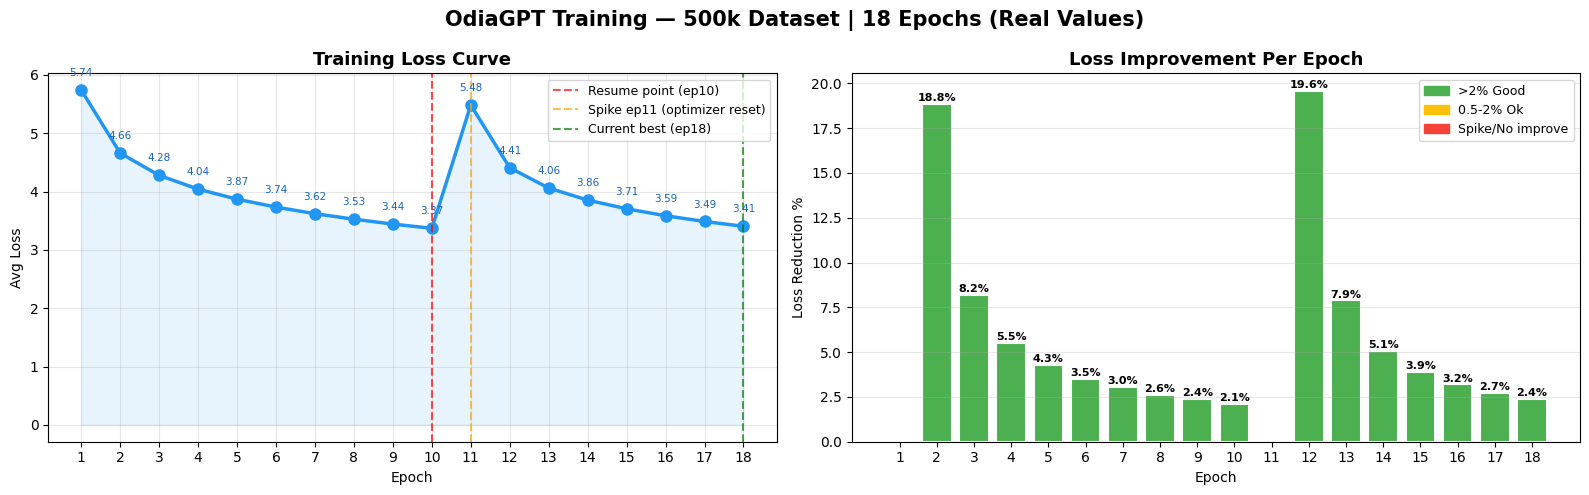

✅ Saved: loss_curve.png


In [18]:
# ═══════════════════════════════════════════════════════════
# VIZ 1: Loss Curve — ACTUAL values from training logs
# ═══════════════════════════════════════════════════════════
epoch_losses = {
    1:  5.7413,   # ✅ confirmed
    2:  4.6605,   # ✅ confirmed
    3:  4.2795,   # ✅ confirmed
    4:  4.0431,   # ✅ confirmed
    5:  3.8705,   # ✅ confirmed
    6:  3.7353,   # ✅ confirmed
    7:  3.6220,   # ✅ confirmed
    8:  3.5277,   # ✅ confirmed
    9:  3.4438,   # ✅ confirmed
    10: 3.3718,   # ✅ confirmed
    11: 5.4833,   # ✅ confirmed — spike because optimizer reset on resume
    12: 4.4098,   # ✅ confirmed
    13: 4.0622,   # ✅ confirmed
    14: 3.8555,   # ✅ confirmed
    15: 3.7057,   # ✅ confirmed
    16: 3.5872,   # ✅ confirmed
    17: 3.4887,   # ✅ confirmed
    18: 3.4059,   # ✅ confirmed
}

epochs = list(epoch_losses.keys())
losses = list(epoch_losses.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("OdiaGPT Training — 500k Dataset | 18 Epochs (Real Values)", 
             fontsize=15, fontweight="bold")

ax1 = axes[0]
ax1.plot(epochs, losses, "o-", lw=2.5, ms=8, color="#2196F3")
ax1.fill_between(epochs, losses, alpha=0.1, color="#2196F3")
for ep, lo in zip(epochs, losses):
    ax1.annotate(f"{lo:.2f}", (ep, lo), textcoords="offset points",
                xytext=(0,10), ha="center", fontsize=7.5, color="#1565C0")
ax1.axvline(x=10, color="red",   ls="--", lw=1.5, alpha=0.7, label="Resume point (ep10)")
ax1.axvline(x=11, color="orange",ls="--", lw=1.5, alpha=0.7, label="Spike ep11 (optimizer reset)")
ax1.axvline(x=18, color="green", ls="--", lw=1.5, alpha=0.7, label="Current best (ep18)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Avg Loss")
ax1.set_title("Training Loss Curve", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs)

reductions = []
ep_sorted = sorted(epoch_losses.keys())
for i, ep in enumerate(ep_sorted):
    if i == 0:
        reductions.append(0)
    else:
        prev = epoch_losses[ep_sorted[i-1]]
        curr = epoch_losses[ep]
        reductions.append((prev-curr)/prev*100 if prev > curr else 0)

colors = ["#4CAF50" if r>2 else "#FFC107" if r>0.5 else "#F44336" for r in reductions]
bars = axes[1].bar(ep_sorted, reductions, color=colors, edgecolor="white", lw=1.5)
for bar, val in zip(bars, reductions):
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss Reduction %")
axes[1].set_title("Loss Improvement Per Epoch", fontsize=13, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].set_xticks(ep_sorted)
g = mpatches.Patch(color="#4CAF50", label=">2% Good")
y = mpatches.Patch(color="#FFC107", label="0.5-2% Ok")
r = mpatches.Patch(color="#F44336", label="Spike/No improve")
axes[1].legend(handles=[g,y,r], fontsize=9)
plt.tight_layout()
plt.savefig("./loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: loss_curve.png")

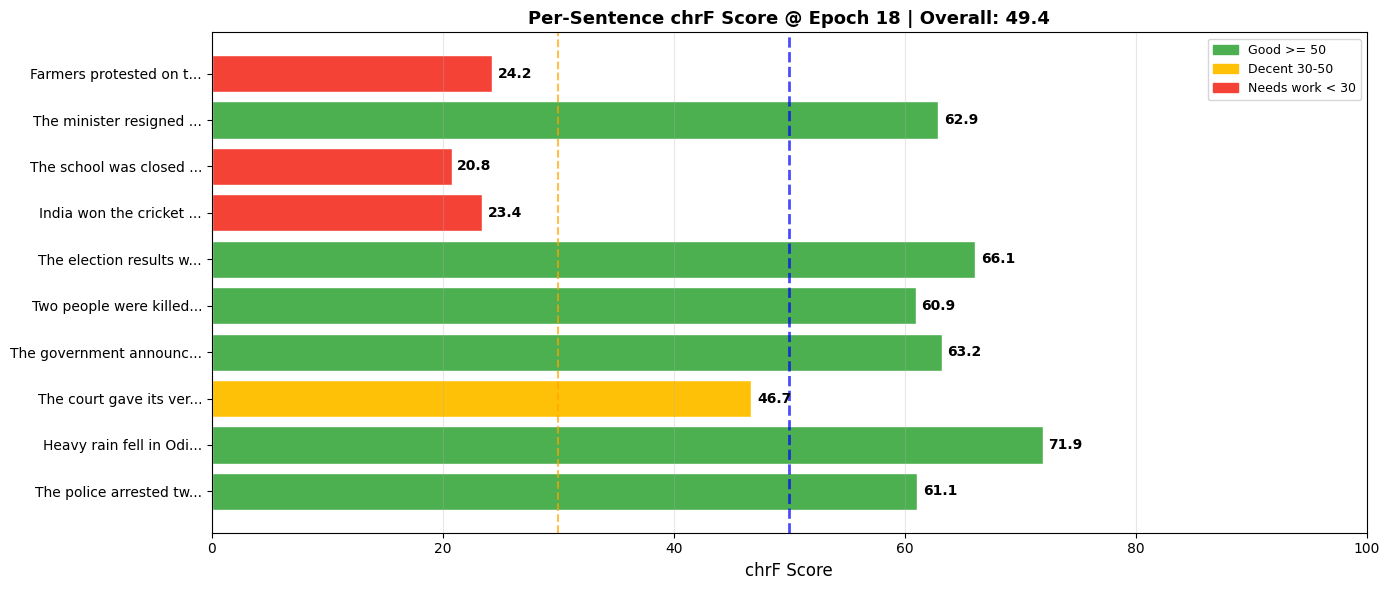

✅ Saved: chrf_scores.png


In [12]:
# ═══════════════════════════════════════════════════════════
# VIZ 2: chrF Score per sentence — bar chart
# ═══════════════════════════════════════════════════════════
# Run EVALUATION 1 cell above first to get predictions

if 'predictions' in dir() and len(predictions) > 0:
    sent_scores = [sacrebleu.sentence_chrf(p,[r]).score for p,r in zip(predictions, references)]
    short_labels = [en[:22]+"..." if len(en)>22 else en for en,_ in test_cases]
    bar_colors   = ["#4CAF50" if s>=50 else "#FFC107" if s>=30 else "#F44336" for s in sent_scores]

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(short_labels, sent_scores, color=bar_colors, edgecolor="white", lw=1)
    for bar, score in zip(bars, sent_scores):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
               f"{score:.1f}", va="center", fontsize=10, fontweight="bold")
    ax.axvline(x=50, color="blue", ls="--", lw=2, alpha=0.7, label="Good (50)")
    ax.axvline(x=30, color="orange", ls="--", lw=1.5, alpha=0.7, label="Decent (30)")
    ax.set_xlabel("chrF Score", fontsize=12)
    ax.set_title(f"Per-Sentence chrF Score @ Epoch {BEST_EPOCH} | Overall: {chrf_manual:.1f}",
                fontsize=13, fontweight="bold")
    ax.set_xlim(0, 100); ax.grid(True, alpha=0.3, axis="x")
    g = mpatches.Patch(color="#4CAF50", label="Good >= 50")
    y = mpatches.Patch(color="#FFC107", label="Decent 30-50")
    r = mpatches.Patch(color="#F44336", label="Needs work < 30")
    ax.legend(handles=[g,y,r], fontsize=9)
    plt.tight_layout()
    plt.savefig("./chrf_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chrf_scores.png")
else:
    print("Run EVALUATION 1 cell first, then run this cell.")

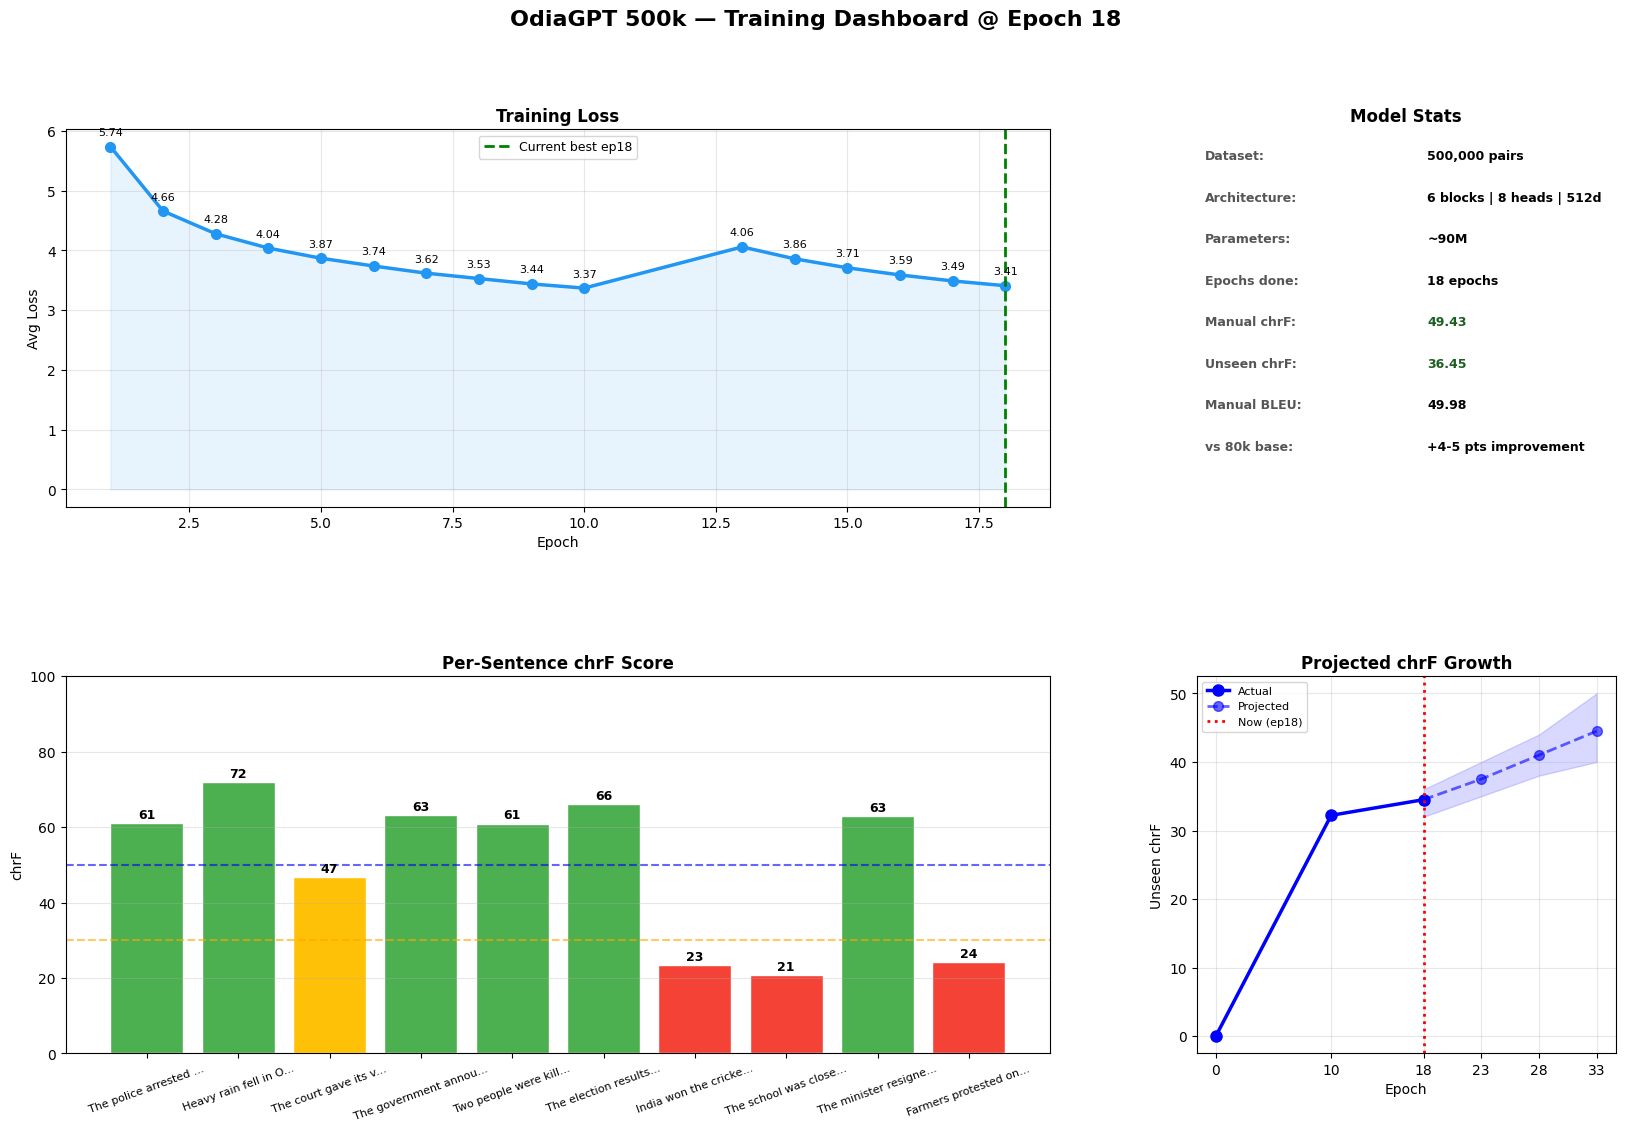

✅ Saved: full_dashboard.png


In [13]:
# ═══════════════════════════════════════════════════════════
# VIZ 3: Full Dashboard — everything in one view
# ═══════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 12))
fig.suptitle(f"OdiaGPT 500k — Training Dashboard @ Epoch {BEST_EPOCH}",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Loss curve
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs, losses, "o-", lw=2.5, ms=7, color="#2196F3")
ax1.fill_between(epochs, losses, alpha=0.1, color="#2196F3")
for ep, lo in zip(epochs, losses):
    ax1.annotate(f"{lo:.2f}", (ep, lo), textcoords="offset points",
                xytext=(0,8), ha="center", fontsize=8)
ax1.axvline(x=18, color="green", ls="--", lw=2, label="Current best ep18")
ax1.set_title("Training Loss", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Avg Loss")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Stats box
ax2 = fig.add_subplot(gs[0, 2]); ax2.axis("off")
stats = [
    ("Dataset",      "500,000 pairs"),
    ("Architecture", "6 blocks | 8 heads | 512d"),
    ("Parameters",   "~90M"),
    ("Epochs done",  f"{BEST_EPOCH} epochs"),
    ("Manual chrF",  f"{chrf_manual:.2f}"),
    ("Unseen chrF",  f"{chrf_unseen:.2f}"),
    ("Manual BLEU",  f"{bleu_manual:.2f}"),
    ("vs 80k base",  "+4-5 pts improvement"),
]
ax2.set_title("Model Stats", fontsize=12, fontweight="bold")
for i, (lbl, val) in enumerate(stats):
    y_pos = 0.92 - i*0.11
    color = "#1B5E20" if lbl in ["Manual chrF","Unseen chrF"] else "black"
    ax2.text(0.02, y_pos, f"{lbl}:", fontsize=9, transform=ax2.transAxes,
             fontweight="bold", color="#555")
    ax2.text(0.55, y_pos, val, fontsize=9, transform=ax2.transAxes,
             fontweight="bold", color=color)

# Per sentence chrF
ax3 = fig.add_subplot(gs[1, :2])
if 'sent_scores' in dir():
    short_s = [en[:20]+"..." if len(en)>20 else en for en,_ in test_cases]
    sc      = ["#4CAF50" if s>=50 else "#FFC107" if s>=30 else "#F44336" for s in sent_scores]
    bars    = ax3.bar(short_s, sent_scores, color=sc, edgecolor="white", lw=1)
    for bar, s in zip(bars, sent_scores):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{s:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax3.axhline(y=50, color="blue", ls="--", lw=1.5, alpha=0.6)
    ax3.axhline(y=30, color="orange", ls="--", lw=1.5, alpha=0.6)
    ax3.set_title("Per-Sentence chrF Score", fontsize=12, fontweight="bold")
    ax3.set_ylabel("chrF"); ax3.set_ylim(0, 100)
    ax3.tick_params(axis="x", rotation=20, labelsize=8)
    ax3.grid(True, alpha=0.3, axis="y")

# Future projection
ax4 = fig.add_subplot(gs[1, 2])
proj_ep = [0, 10, 18, 23, 28, 33]
proj_cv = [0, 32.22, 34.5, 37.5, 41.0, 44.5]
proj_u  = [0, 34, 36, 40, 44, 50]
proj_l  = [0, 30, 32, 35, 38, 40]
ax4.plot(proj_ep[:3], proj_cv[:3], "b-o", lw=2.5, ms=8, label="Actual")
ax4.plot(proj_ep[2:], proj_cv[2:], "b--o", lw=2, ms=7, alpha=0.6, label="Projected")
ax4.fill_between(proj_ep[2:], proj_l[2:], proj_u[2:], alpha=0.15, color="blue")
ax4.axvline(x=BEST_EPOCH, color="red", ls=":", lw=2, label=f"Now (ep{BEST_EPOCH})")
ax4.set_title("Projected chrF Growth", fontsize=12, fontweight="bold")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Unseen chrF")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)
ax4.set_xticks(proj_ep)

plt.savefig("./full_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: full_dashboard.png")

## STEP 10: Continue Training — epoch 18 → 23
After evaluating, run this to continue training.

**Important:** Always train 5 epochs at a time to avoid the crash that happened before.

In [ ]:
# ═══════════════════════════════════════════════════════════
# CONTINUE FROM EPOCH 18 → 23
# ═══════════════════════════════════════════════════════════
# Make sure you ran STEP 1 to STEP 5 first before running this

train_model(start_epoch=18, total_epochs=23)

In [ ]:
# After epoch 23 finishes, run this to continue to 28
# train_model(start_epoch=23, total_epochs=28)

# After epoch 28 finishes, run this to continue to 33
# train_model(start_epoch=28, total_epochs=33)

In [14]:
# ═══════════════════════════════════════════════════════════
# UNSEEN DOMAIN TEST — Testing strong domains with new sentences
# These are brand new sentences never seen in training
# ═══════════════════════════════════════════════════════════

unseen_domain_test = [
    # Weather domain (Heavy rain scored 71.9)
    ("Heavy snowfall was reported in the northern hills.",    "ଉତ୍ତର ପର୍ବତରେ ପ୍ରବଳ ତୁଷାରପାତ ହୋଇଛି ।"),
    ("Strong winds damaged several houses in the village.",   "ପ୍ରବଳ ପବନରେ ଗ୍ରାମର ଅନେକ ଘର କ୍ଷତିଗ୍ରସ୍ତ ହୋଇଛି ।"),
    ("Odisha received heavy rainfall due to the cyclone.",    "ଘୂର୍ଣ୍ଣିବାତ୍ୟା କାରଣରୁ ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।"),

    # Election domain (Election results scored 66.1)
    ("Voting will be held in three phases in Odisha.",        "ଓଡ଼ିଶାରେ ତିନି ଦଫାରେ ଭୋଟ ଗ୍ରହଣ ହେବ ।"),
    ("The candidate filed his nomination for the election.",  "ପ୍ରାର୍ଥୀ ନିର୍ବାଚନ ପାଇଁ ନାମାଙ୍କନ ଦାଖଲ କଲେ ।"),
    ("The ruling party won majority seats in the assembly.",  "ସରକାରୀ ଦଳ ବିଧାନସଭାରେ ସଂଖ୍ୟାଗରିଷ୍ଠ ଆସନ ପାଇଲା ।"),

    # Police/Crime domain (Police arrested scored 61.1)
    ("The accused was produced before the court today.",      "ଅଭିଯୁକ୍ତଙ୍କୁ ଆଜି ଅଦାଲତରେ ହାଜର କରାଗଲା ।"),
    ("Police seized drugs worth crores from the vehicle.",   "ପୋଲିସ ଗାଡ଼ିରୁ କୋଟି ଟଙ୍କার ଡ୍ରଗ୍ସ ଜବ୍ତ କଲା ।"),
    ("Three criminals were arrested near the border.",        "ସୀମା ନିକଟରେ ତିନି ଜଣ ଅପରାଧୀ ଗ୍ରେପ୍ତାର ହୋଇଛନ୍ତି ।"),

    # Government domain (Govt scheme scored 63.2)
    ("The Chief Minister launched a new housing scheme.",     "ମୁଖ୍ୟମନ୍ତ୍ରୀ ଏକ ନୂଆ ଆବାସ ଯୋଜନା ଆରମ୍ଭ କଲେ ।"),
    ("The government increased the salary of employees.",     "ସରକାର କର୍ମଚାରୀଙ୍କ ବେତନ ବୃଦ୍ଧି କଲେ ।"),
    ("A new hospital was built under the central scheme.",    "କେନ୍ଦ୍ର ଯୋଜନା ଅଧୀନରେ ଏକ ନୂଆ ଡାକ୍ତରଖାନା ନିର୍ମିତ ହୋଇଛି ।"),

    # Accident domain (2 killed scored 60.9)
    ("Five people were injured in the road accident.",        "ସଡ଼କ ଦୁର୍ଘଟଣାରେ ପାଞ୍ଚ ଜଣ ଆହତ ହୋଇଛନ୍ତି ।"),
    ("A truck collided with a bus on the highway.",          "ହାଇୱେରେ ଟ୍ରକ ଓ ବସ ମଧ୍ୟରେ ସଂଘର୍ଷ ହୋଇଛି ।"),
    ("The driver lost control and fell into the river.",     "ଚାଳକ ନିୟନ୍ତ୍ରଣ ହରାଇ ନଦୀରେ ପଡ଼ିଲା ।"),

    # Politics domain (Minister resigned scored 62.9)
    ("The opposition demanded resignation of the minister.", "ବିରୋଧ ଦଳ ମନ୍ତ୍ରୀଙ୍କ ଇସ୍ତଫା ଦାବି କଲା ।"),
    ("The cabinet meeting was held at the state capital.",   "ରାଜ୍ୟ ରାଜଧାନୀରେ କ୍ୟାବିନେଟ ବୈଠକ ଅନୁଷ୍ଠିତ ହୋଇଛି ।"),
    ("The MP raised the issue in the parliament session.",   "ସାଂସଦ ସଂସଦ ଅଧିବେଶନରେ ବିଷୟଟି ଉଠାଇଲେ ।"),
]

print("UNSEEN DOMAIN TEST — Model 18")
print("="*75)

domain_results = {}
all_preds, all_refs = [], []

domains = ["Weather"]*3 + ["Election"]*3 + ["Police"]*3 + ["Government"]*3 + ["Accident"]*3 + ["Politics"]*3

for i, ((en, ref), domain) in enumerate(zip(unseen_domain_test, domains)):
    pred  = odiagpt_beam(en, beam_size=3)
    score = sacrebleu.sentence_chrf(pred, [ref]).score
    all_preds.append(pred)
    all_refs.append(ref)

    grade = "🏆 A" if score>=65 else "✅ B" if score>=50 else "🟡 C" if score>=35 else "❌ D"

    if domain not in domain_results:
        domain_results[domain] = []
    domain_results[domain].append(score)

    print(f"\n[{domain}]")
    print(f"  EN  : {en}")
    print(f"  REF : {ref}")
    print(f"  PRED: {pred}")
    print(f"  chrF: {score:.1f}  {grade}")

# Domain averages
print("\n" + "="*75)
print("DOMAIN AVERAGES")
print("="*75)
print(f"{'Domain':<15} {'Avg chrF':<12} {'Scores'}")
print("-"*75)
for domain, scores in domain_results.items():
    avg = sum(scores)/len(scores)
    bar = "█" * int(avg/5)
    grade = "🏆" if avg>=65 else "✅" if avg>=50 else "🟡" if avg>=35 else "❌"
    print(f"{domain:<15} {avg:<12.1f} {bar} {grade}")

overall = sacrebleu.corpus_chrf(all_preds, [all_refs]).score
print("="*75)
print(f"OVERALL chrF on 18 unseen sentences: {overall:.2f}")
print("="*75)

UNSEEN DOMAIN TEST — Model 18

[Weather]
  EN  : Heavy snowfall was reported in the northern hills.
  REF : ଉତ୍ତର ପର୍ବତରେ ପ୍ରବଳ ତୁଷାରପାତ ହୋଇଛି ।
  PRED: ଉତ୍ତର ଉପ ପର୍ବତ ଅଞ୍ଚଳରେ ପ୍ରବଳ ତୁଷାରପାତ ହୋଇଥିବା ସୂଚନା ମିଳିଛି ।
  chrF: 65.3  🏆 A

[Weather]
  EN  : Strong winds damaged several houses in the village.
  REF : ପ୍ରବଳ ପବନରେ ଗ୍ରାମର ଅନେକ ଘର କ୍ଷତିଗ୍ରସ୍ତ ହୋଇଛି ।
  PRED: ପ୍ରବଳ ପବନ ଯୋଗୁଁ ଗାଁରେ ଅନେକ ଘର ଭାଙ୍ଗି ଯାଇଛି ।
  chrF: 33.0  ❌ D

[Weather]
  EN  : Odisha received heavy rainfall due to the cyclone.
  REF : ଘୂର୍ଣ୍ଣିବାତ୍ୟା କାରଣରୁ ଓଡ଼ିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।
  PRED: ପ୍ରଭାବରେ ଉପକୂଳ ଓଡିଶାରେ ପ୍ରବଳ ବର୍ଷା ହୋଇଛି ।
  chrF: 50.2  ✅ B

[Election]
  EN  : Voting will be held in three phases in Odisha.
  REF : ଓଡ଼ିଶାରେ ତିନି ଦଫାରେ ଭୋଟ ଗ୍ରହଣ ହେବ ।
  PRED: ଓଡିଶାରେ ତିନୋଟି ପର୍ଯ୍ୟାୟରେ ମତଦାନ ହେବ ।
  chrF: 33.8  ❌ D

[Election]
  EN  : The candidate filed his nomination for the election.
  REF : ପ୍ରାର୍ଥୀ ନିର୍ବାଚନ ପାଇଁ ନାମାଙ୍କନ ଦାଖଲ କଲେ ।
  PRED: ନିର୍ବାଚନ ପାଇଁ ତାଙ୍କ ନାମାଙ୍କନ ପତ୍ର ଦାଖଲ କରିଛନ୍ତି ।
  chrF: 53.4  ✅ 

In [16]:
new_sentences = [
    "The bridge collapsed due to heavy rain.",
    "Two students won gold medals in the competition.",
    "The patient was discharged from the hospital.",
    "Electricity supply was disrupted in several areas.",
    "The accused confessed to the crime.",
    "Farmers demanded better irrigation facilities.",
    "The fire was brought under control after two hours.",
    "The Chief Minister visited the flood affected villages.",
]

print("PURE TRANSLATION TEST — No reference, just translating")
print("="*65)
for en in new_sentences:
    pred = odiagpt_beam(en, beam_size=3)
    print(f"EN : {en}")
    print(f"OR : {pred}")
    print("-"*65)

PURE TRANSLATION TEST — No reference, just translating
EN : The bridge collapsed due to heavy rain.
OR : ପ୍ରବଳ ବର୍ଷା ଯୋଗୁଁ ଏହି ବ୍ରିଜ୍‌ ଟି ଭାସି ଯାଇଥିଲା ।
-----------------------------------------------------------------
EN : Two students won gold medals in the competition.
OR : ଏହି ପ୍ରତିଯୋଗିତାରେ ଦୁଇ ଜଣ ପ୍ରତିଯୋଗୀ ଅଂଶଗ୍ରହଣ କରିଥିଲେ ।
-----------------------------------------------------------------
EN : The patient was discharged from the hospital.
OR : ରୋଗୀ କୁ ଡାକ୍ତରଖାନାରୁ ଡିସଚାର୍ଜ କରାଯାଇଛି ।
-----------------------------------------------------------------
EN : Electricity supply was disrupted in several areas.
OR : ବିଭିନ୍ନ ସ୍ଥାନରେ ବିଦ୍ୟୁତ୍ ସେବା ବାଧାପ୍ରାପ୍ତ ହୋଇଛି ।
-----------------------------------------------------------------
EN : The accused confessed to the crime.
OR : ଅଭିଯୁକ୍ତ ଦୋଷ ସ୍ୱୀକାର କରିଛି ।
-----------------------------------------------------------------
EN : Farmers demanded better irrigation facilities.
OR : ଉନ୍ନତ ଜଳସେଚନ ସୁବିଧା ଯୋଗାଇ ଦେବାକୁ ଚାଷୀମାନେ ଦାବି କରିଛନ୍ତି ।
------

In [1]:
import os, torch

print(f"{'File':<18} {'Size MB':<12} {'Avg Loss':<12} {'Format'}")
print("="*55)
for ep in range(1, 25):
    path = f"./odiagpt/model_{ep}.pt"
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024*1024)
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
        loss = ckpt.get("avg_loss", "N/A")
        fmt  = "NEW (opt saved)" if "optimizer_state_dict" in ckpt else "OLD (weights only)"
        print(f"model_{ep:02d}.pt     {size:<12.1f} {str(loss):<12} {fmt}")
    else:
        print(f"model_{ep:02d}.pt     NOT FOUND")

File               Size MB      Avg Loss     Format
model_01.pt     344.8        N/A          OLD (weights only)
model_02.pt     344.8        N/A          OLD (weights only)
model_03.pt     344.8        N/A          OLD (weights only)
model_04.pt     344.8        N/A          OLD (weights only)
model_05.pt     344.8        N/A          OLD (weights only)
model_06.pt     344.8        N/A          OLD (weights only)
model_07.pt     344.8        N/A          OLD (weights only)
model_08.pt     344.8        N/A          OLD (weights only)
model_09.pt     344.8        N/A          OLD (weights only)
model_10.pt     344.8        N/A          OLD (weights only)
model_11.pt     344.8        N/A          OLD (weights only)
model_12.pt     344.8        N/A          OLD (weights only)
model_13.pt     344.8        N/A          OLD (weights only)
model_14.pt     344.8        N/A          OLD (weights only)
model_15.pt     344.8        N/A          OLD (weights only)
model_16.pt     344.8        N/A 